In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_75_4885.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_108_9034.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_121_7141.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_183_3960.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_113_2811.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_257_8393.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_225_4291.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_110_2513.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/1017.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug_204_7608.png
/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images/aug

In [2]:
image_dir = "/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Images"
mask_dir = "/kaggle/input/datasets/saiharshitjami/flood-images-mask-segmentation/Masks"

In [3]:
images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

In [4]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T

class FloodDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

        self.img_transform = T.Compose([
            T.Resize((256, 256)),
            T.ToTensor(),
        ])

        self.mask_transform = T.Compose([
            T.Resize((256, 256)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx): 
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        try:
            image = Image.open(img_path).convert("RGB")
            mask = Image.open(mask_path).convert("L")
        except:
            return self.__getitem__((idx + 1) % len(self.images))

        image = self.img_transform(image)
        mask = self.mask_transform(mask)

        mask = (mask > 0).float()

        return image, mask

In [5]:
from torch.utils.data import DataLoader

dataset = FloodDataset(image_dir, mask_dir)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

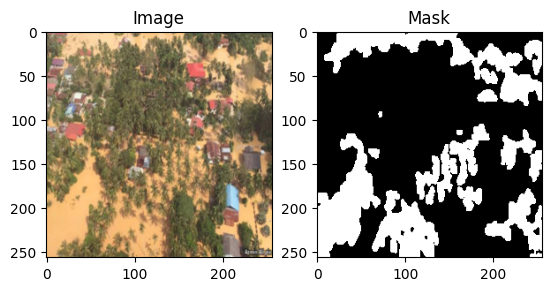

In [6]:
import matplotlib.pyplot as plt

img, mask = dataset[0]

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Mask")

plt.show()

In [7]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 1, 1) 

    def forward(self, x):
        return self.conv(x)

In [8]:
model = UNet().cuda()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [9]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.cuda()
        masks = masks.cuda()

        preds = model(imgs)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader):.4f}")

Epoch 1, Loss: 0.7071
Epoch 2, Loss: 0.6847
Epoch 3, Loss: 0.6662
Epoch 4, Loss: 0.6510
Epoch 5, Loss: 0.6388
